<a href="https://colab.research.google.com/github/aadityane93/Deep_Learning/blob/main/Topic_3_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exercises — Deep Learning for Computer Vision (Ch. 8)
**Seminar: Current Topics in AI**



---
## Setup — Run this first (no code to write)
Just run the next cell once. Wait until you see Setup complete!`


In [1]:

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(train_images_raw, train_labels), (test_images_raw, test_labels) = mnist.load_data()

# Reshape + normalize
train_images = train_images_raw.reshape((60000, 28, 28, 1)).astype("float32") / 255
test_images = test_images_raw.reshape((10000, 28, 28, 1)).astype("float32") / 255

# Reserve 10,000 for validation
x_val = train_images[:10000]
partial_x_train = train_images[10000:]
y_val = train_labels[:10000]
partial_y_train = train_labels[10000:]

print(" Setup complete!")
print(f"partial_x_train: {partial_x_train.shape}   x_val: {x_val.shape}")
print(f"test_images: {test_images.shape}   test_labels: {test_labels.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Setup complete!
partial_x_train: (50000, 28, 28, 1)   x_val: (10000, 28, 28, 1)
test_images: (10000, 28, 28, 1)   test_labels: (10000,)


---
## Exercise 1 — Build Your First ConvNet

### Goal
Build a simple ConvNet with **2 Conv2D layers**.

### Model idea
`Input -> Conv2D -> Conv2D -> Flatten -> Dense`

### What to remember
- `Conv2D` learns image features such as edges and patterns
- `Flatten()` changes the 3D output into a 1D vector
- `Dense(10, softmax)` is used because MNIST has **10 classes** (digits 0–9)

### Hint
A good pattern is:
```python
layers.Conv2D(.. , .. , activation='...')(inputs)
layers.Conv2D(64, 3, activation='..')(x)
layers.Dense(.. , activation='...')(x)
```


In [2]:
inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu")(inputs)
x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_ex1 = keras.Model(inputs, outputs)

model_ex1.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_ex1.summary()

history_ex1 = model_ex1.fit(
    partial_x_train,
    partial_y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss_ex1, test_acc_ex1 = model_ex1.evaluate(test_images, test_labels, verbose=0)
print(f"Exercise 1 test accuracy: {test_acc_ex1:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       368,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,466 (1.48 MB)

 Trainable params: 387,466 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 134ms/step - accuracy: 0.9549 - loss: 0.1476 - val_accuracy: 0.9771 - val_loss: 0.0813
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 130ms/step - accuracy: 0.9834 - loss: 0.0546 - val_accuracy: 0.9808 - val_loss: 0.0661
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.9881 - loss: 0.0381 - val_accuracy: 0.9835 - val_loss: 0.0590
Exercise 1 test accuracy: 0.9854


### Extra hint for Exercise 1
If you are stuck, check:
- the first convolution layer should use `inputs`
- the second convolution layer should use the previous `x`
- the final output layer should use `softmax` with `10` units


---
## Exercise 2 — Add MaxPooling Layers

### Goal
Add pooling so the model becomes more efficient.

### Why pooling helps
- It makes feature maps smaller
- It reduces the number of values the model must process
- It often helps the model focus on important patterns

### Architecture
`Input -> Conv(32) -> Pool -> Conv(64) -> Pool -> Conv(128) -> Flatten -> Dense(10)`

### Hint
A pooling layer can look like this:
```python
layers.MaxPooling2D(2)(x)
```

You need that idea **two times** in this exercise.


In [4]:
#  Build the model with MaxPooling
inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu")(inputs)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_ex2 = keras.Model(inputs, outputs)

#  Compile
model_ex2.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#  Train
history_ex2 = model_ex2.fit(
    partial_x_train,
    partial_y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

# Test accuracy
test_loss_ex2, test_acc_ex2 = model_ex2.evaluate(test_images, test_labels, verbose=0)
print(f"Exercise 2 test accuracy: {test_acc_ex2:.4f}")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.9457 - loss: 0.1756 - val_accuracy: 0.9810 - val_loss: 0.0635
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9825 - val_loss: 0.0573
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9873 - val_loss: 0.0415
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.9925 - loss: 0.0240 - val_accuracy: 0.9900 - val_loss: 0.0342
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9940 - loss: 0.0192 - val_accuracy: 0.9887 - val_loss: 0.0440
Exercise 2 test accuracy: 0.9908


### Extra hint for Exercise 2
Check that:
- each pooling layer uses the current `x`
- pooling comes after a convolution layer
- the last convolution layer still comes before `Flatten()`


---
## Exercise 3 — Compare the Two Models

### Goal
Plot the validation accuracy of:
- Exercise 1 model
- Exercise 2 model

### Hint
Use:
```python
history_ex1.history['val_accuracy']
history_ex2.history['val_accuracy']
```

For the second plot line, follow the same structure as the first line:
```python
axes[0].plot(range(1, len(...)+1), ..., 'r-o', label='...')
```


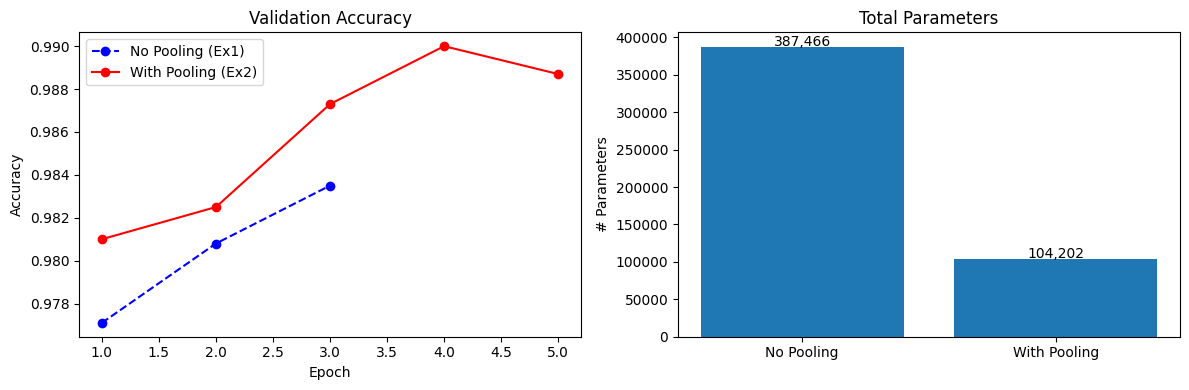

No Pooling:   387,466 parameters
With Pooling: 104,202 parameters
Reduction:    283,264 fewer parameters


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: validation accuracy
axes[0].plot(
    range(1, len(history_ex1.history["val_accuracy"]) + 1),
    history_ex1.history["val_accuracy"],
    "b--o",
    label="No Pooling (Ex1)"
)

axes[0].plot(
    range(1, len(history_ex2.history["val_accuracy"]) + 1),
    history_ex2.history["val_accuracy"],
    "r-o",
    label="With Pooling (Ex2)"
)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Right: parameter count
params_ex1 = model_ex1.count_params()
params_ex2 = model_ex2.count_params()

axes[1].bar(["No Pooling", "With Pooling"], [params_ex1, params_ex2])
axes[1].set_title("Total Parameters")
axes[1].set_ylabel("# Parameters")

for i, v in enumerate([params_ex1, params_ex2]):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"No Pooling:   {params_ex1:,} parameters")
print(f"With Pooling: {params_ex2:,} parameters")
print(f"Reduction:    {params_ex1 - params_ex2:,} fewer parameters")

### Extra hint for Exercise 3
To finish the comparison:
- use the validation accuracy from `history_ex2`
- keep the same `range(...)` pattern as the first plot
- choose a clear label such as `"With Pooling (Ex2)"`

### Very short conclusion examples
- "The model with pooling uses fewer parameters and still performs very well."
- "Pooling reduces parameters and usually improves efficiency."


---
## Exercise 4 — Build a Deeper Model

### Goal
Add more convolution layers and check whether deeper is always better.

### Target idea
`Input -> Conv(32)+Pool -> Conv(64)+Pool -> Conv(128)+Pool -> Conv(256) -> Flatten -> Dense(10)`

### Hint
Useful layer patterns are:
```python
x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.Conv2D(256, 3, activation='relu')(x)
optimizer="rmsprop",loss="sparse_categorical_crossentropy",metrics=["accuracy"]
```


In [8]:

#  Build the deeper model
inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu")(inputs)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation="relu")(x)

x = layers.Conv2D(256, 3, activation="relu")(x)

x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_ex4 = keras.Model(inputs, outputs)

#  Compile
model_ex4.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4c. Train
history_ex4 = model_ex4.fit(
    partial_x_train,
    partial_y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

# Evaluate
test_loss_ex4, test_acc_ex4 = model_ex4.evaluate(test_images, test_labels, verbose=0)

print("-" * 45)
print(f"Exercise 2 test accuracy: {test_acc_ex2:.4f}")
print(f"Exercise 4 test accuracy: {test_acc_ex4:.4f}")
print("-" * 45)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 82ms/step - accuracy: 0.9488 - loss: 0.1592 - val_accuracy: 0.9809 - val_loss: 0.0599
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.9868 - loss: 0.0427 - val_accuracy: 0.9871 - val_loss: 0.0469
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.9910 - loss: 0.0299 - val_accuracy: 0.9885 - val_loss: 0.0427
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9935 - loss: 0.0216 - val_accuracy: 0.9906 - val_loss: 0.0356
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9906 - val_loss: 0.0415
---------------------------------------------
Exercise 2 test accuracy: 0.9908
Exercise 4 test accuracy: 0.9932
---------------------------------------------


### Extra hint for Exercise 4
Check that:
- the new layers are added before `Flatten()`
- the compile settings can stay the same as earlier exercises
- the output layer should still predict 10 classes


---
## Exercise 5 — Data Augmentation

### Goal
Add augmentation before the ConvNet.

### Why do this?
It creates slightly changed training images, which can help the model generalize better.

### Hint
Common augmentation layers include:
```python
layers.RandomFlip("..")
layers.RandomRotation(0.1)
layers.RandomZoom(0.2)
```


In [7]:

#  data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

inputs = keras.Input(shape=(28, 28, 1))
x = data_augmentation(inputs)

x = layers.Conv2D(32, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_bonus = keras.Model(inputs, outputs)

model_bonus.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_bonus = model_bonus.fit(
    partial_x_train,
    partial_y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

_, test_acc_bonus = model_bonus.evaluate(test_images, test_labels, verbose=0)
print(f" test accuracy: {test_acc_bonus:.4f}")


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.8075 - loss: 0.5817 - val_accuracy: 0.9343 - val_loss: 0.2033
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9225 - loss: 0.2447 - val_accuracy: 0.9552 - val_loss: 0.1351
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.9403 - loss: 0.1863 - val_accuracy: 0.9624 - val_loss: 0.1234
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9498 - loss: 0.1575 - val_accuracy: 0.9670 - val_loss: 0.0950
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.9550 - loss: 0.1406 - val_accuracy: 0.9773 - val_loss: 0.0798
 test accuracy: 0.9785


### Extra hint for Bonus
You can place the augmentation layers inside a small `keras.Sequential([...])` block and apply it to the inputs before the convolution layers.
